## import

In [222]:
from importlib.metadata import version
import nltk
from nltk.corpus import stopwords
from bs4 import BeautifulSoup
import summa

import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import urllib.request
import warnings
from collections import Counter
import pickle


print(nltk.__version__)
print(torch.__version__)
print(pd.__version__)
print(version('summa'))

3.9.4
2.7.1+cu118
2.3.3
1.2.0


In [223]:
warnings.filterwarnings("ignore", category=UserWarning, module='bs4')

## 데이터 준비

In [224]:
# 불용어 다운로드
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [225]:
# 데이터 다운로드
urllib.request.urlretrieve("https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv", filename="news_summary_more.csv")

('news_summary_more.csv', <http.client.HTTPMessage at 0x18da6298f70>)

In [226]:
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

In [227]:
data.sample(10)

,headlines,text
84660,Italy rules lobsters cannot be kept on ice bef...,Italy's highest court ruled on Friday that liv...
1741,Northern Ireland footballer filmed masturbatin...,Northern Ireland footballer Gavin Whyte was ca...
26248,24-yr-old sexually abused man asks President f...,A 24-year-old Andhra Pradesh man has sought Pr...
36366,20 students killed as school bus falls into go...,At least 20 students have been killed after a ...
74941,Over 15% growth in foreign tourist arrival in ...,India has seen a growth of over 15% in foreign...
48243,7 Mexican states on alert over stolen radioact...,Seven Mexican states have been put on alert af...
25190,The Viral Fever raises $6 million from Tiger G...,Online video platform The Viral Fever (TVF) ha...
88583,WikiLeaks source Chelsea Manning released from...,US transgender soldier Chelsea Manning who was...
34898,"FB, Microsoft pledge to defend against misuse ...","Facebook, Microsoft and 32 other global techno..."
80409,Elon Musk asks meaning of domain provider GoDa...,"Tesla and SpaceX's billionaire Founder, Elon M..."


## 데이터 전처리 (추상적 요약)
### 중복 샘플과 NULL 값이 존재하는 샘플 제거

In [228]:
print('headlines 열에서 중복을 배제한 유일한 샘플의 수 :', data['headlines'].nunique())
print('text 열에서 중복을 배제한 유일한 샘플의 수 :', data['text'].nunique())

headlines 열에서 중복을 배제한 유일한 샘플의 수 : 98280
text 열에서 중복을 배제한 유일한 샘플의 수 : 98360


In [229]:
# inplace=True 를 설정하면 DataFrame 타입 값을 return 하지 않고 data 내부를 직접적으로 바꿉니다
data.drop_duplicates(subset = ['headlines'], inplace=True)
print('전체 샘플수 :', (len(data)))
data.drop_duplicates(subset = ['text'], inplace=True)
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98280
전체 샘플수 : 98262


In [230]:
print(data.isnull().sum())

headlines    0
text         0
dtype: int64


### 텍스트 정규화와 불용어 제거

In [231]:
contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

print("정규화 사전의 수: ", len(contractions))

정규화 사전의 수:  120


In [232]:
print('불용어 개수 :', len(stopwords.words('english') ))
print(stopwords.words('english'))

불용어 개수 : 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "

In [233]:
# Set 자료형으로 만들어 검색 속도 극대화
stop_words = set(stopwords.words('english'))

# 데이터 전처리 함수
def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower() # 텍스트 소문자화
    sentence = BeautifulSoup(sentence, "lxml").text # <br />, <a href = ...> 등의 html 태그 제거
    sentence = re.sub(r'\([^)]*\)', '', sentence) # 괄호로 닫힌 문자열 (...) 제거 Ex) my husband (and myself!) for => my husband for
    sentence = re.sub('"','', sentence) # 쌍따옴표 " 제거
    sentence = ' '.join([contractions[t] if t in contractions else t for t in sentence.split(" ")]) # 약어 정규화
    sentence = re.sub(r"'s\b","", sentence) # 소유격 제거. Ex) roland's -> roland
    sentence = re.sub("[^a-zA-Z]", " ", sentence) # 영어 외 문자(숫자, 특수문자 등) 공백으로 변환
    sentence = re.sub('[m]{2,}', 'mm', sentence) # m이 3개 이상이면 2개로 변경. Ex) ummmmmmm yeah -> umm yeah

    # 불용어 제거 (text)
    if remove_stopwords:
        tokens = ' '.join(word for word in sentence.split() if not word in stop_words if len(word) > 1)  #속도 향상 
    # 불용어 미제거 (headlines)
    else:
        tokens = ' '.join(word for word in sentence.split() if len(word) > 1)
    return tokens

In [234]:
temp_text1 = 'Everything I bought was great, infact I ordered twice and the third ordered was<br />for my mother and father.'
temp_text2 = 'Great way to start (or finish) the day!!!'

print("text1: ", preprocess_sentence(temp_text1))
print("text2:", preprocess_sentence(temp_text2, False))  # 불용어를 제거하지 않습니다.

text1:  everything bought great infact ordered twice third ordered wasfor mother father
text2: great way to start the day


In [235]:
# 전체 Text 데이터에 대한 전처리 
clean_text = []

for sentence in data['text']:
    clean_text.append(preprocess_sentence(sentence))

# 전처리 후 출력
print("Text 전처리 후 결과: ", clean_text[:5])

Text 전처리 후 결과:  ['saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad degree career support helped transition data scientist tech mahindra salary hike upgrad online power learning powered lakh careers', 'kunal shah credit card bill payment platform cred gave users chance win free food swiggy one year pranav kaushik delhi techie bagged reward spending cred coins users get one cred coin per rupee bill paid used avail rewards brands like ixigo bookmyshow ubereats cult fit', 'new zealand defeated india wickets fourth odi hamilton thursday win first match five match odi series india lost international match rohit sharma captaincy consecutive victories dating back march match witnessed india getting seventh lowest total odi cricket history', 'aegon life iterm insurance plan customers enjoy tax benefits premiums paid save taxes plan provides life cover age years also customers options insur

In [236]:
# 전체 headlines 데이터에 대한 전처리
clean_headlines = []

for sentence in data['headlines']:
    clean_headlines.append(preprocess_sentence(sentence, remove_stopwords=False))

print("headlines 전처리 후 결과: ", clean_headlines[:5])

headlines 전처리 후 결과:  ['upgrad learner switches to career in ml al with salary hike', 'delhi techie wins free food from swiggy for one year on cred', 'new zealand end rohit sharma led india match winning streak', 'aegon life iterm insurance plan helps customers save tax', 'have known hirani for yrs what if metoo claims are not true sonam']


In [237]:
data['text'] = clean_text
data['headlines'] = clean_headlines

# 빈 값을 Null 값으로 변환
data.replace('', np.nan, inplace=True)

In [238]:
data.isnull().sum()

headlines    0
text         0
dtype: int64

In [239]:
data.dropna(axis=0, inplace=True)
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98262


## 훈련 데이터와 테스트 데이터 나누기
### 샘플의 최대 길이 정하기

텍스트의 최소 길이 : 1
텍스트의 최대 길이 : 60
텍스트의 평균 길이 : 35.10029309397326
요약의 최소 길이 : 1
요약의 최대 길이 : 16
요약의 평균 길이 : 9.299444342675704


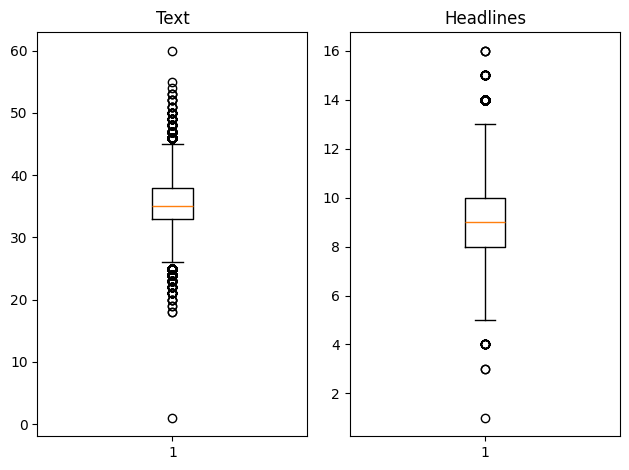

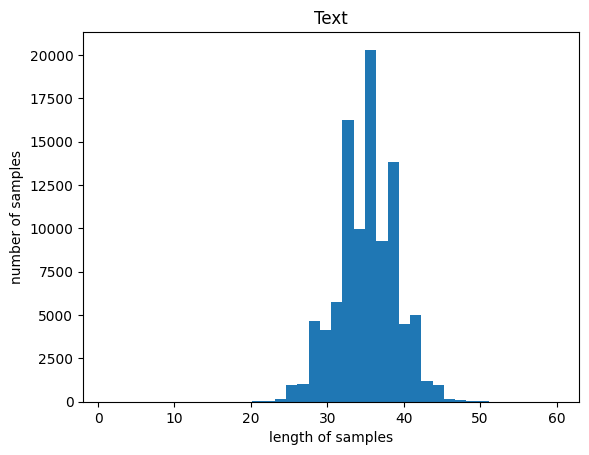

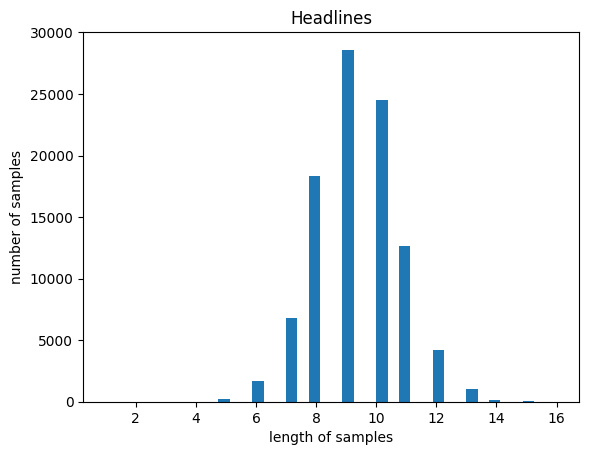

In [240]:
text_len = [len(s.split()) for s in data['text']]
headlines_len = [len(s.split()) for s in data['headlines']]

print('텍스트의 최소 길이 : {}'.format(np.min(text_len)))
print('텍스트의 최대 길이 : {}'.format(np.max(text_len)))
print('텍스트의 평균 길이 : {}'.format(np.mean(text_len)))
print('요약의 최소 길이 : {}'.format(np.min(headlines_len)))
print('요약의 최대 길이 : {}'.format(np.max(headlines_len)))
print('요약의 평균 길이 : {}'.format(np.mean(headlines_len)))

plt.subplot(1,2,1)
plt.boxplot(text_len)
plt.title('Text')
plt.subplot(1,2,2)
plt.boxplot(headlines_len)
plt.title('Headlines')
plt.tight_layout()
plt.show()

plt.title('Text')
plt.hist(text_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

plt.title('Headlines')
plt.hist(headlines_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [241]:
# 정해진 길이보다 큰 샘플 제외 (패딩)

text_max_len = 45
headlines_max_len = 12

In [242]:
# 데이터의 몇 %가 해당하는지 계산하는 함수
def below_threshold_len(max_len, nested_list):
  cnt = 0
  for s in nested_list:
    if(len(s.split()) <= max_len):
        cnt = cnt + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (cnt / len(nested_list))))

In [243]:
below_threshold_len(text_max_len, data['text'])
below_threshold_len(headlines_max_len, data['headlines'])

전체 샘플 중 길이가 45 이하인 샘플의 비율: 0.9967739309193788
전체 샘플 중 길이가 12 이하인 샘플의 비율: 0.9880319960920804


In [244]:
data = data[data['text'].apply(lambda x: len(x.split()) <= text_max_len)]
data = data[data['headlines'].apply(lambda x: len(x.split()) <= headlines_max_len)]

print('전체 샘플수 :', (len(data)))

전체 샘플수 : 96774


### 시작 토큰과 종료 토큰 추가하기

In [245]:
# 헤드라인 데이터에는 시작 토큰과 종료 토큰을 추가한다.
data['decoder_input'] = data['headlines'].apply(lambda x : 'sostoken '+ x)
data['decoder_target'] = data['headlines'].apply(lambda x : x + ' eostoken')
data.head()

,headlines,text,decoder_input,decoder_target
0,upgrad learner switches to career in ml al wit...,saurav kant alumnus upgrad iiit pg program mac...,sostoken upgrad learner switches to career in ...,upgrad learner switches to career in ml al wit...
1,delhi techie wins free food from swiggy for on...,kunal shah credit card bill payment platform c...,sostoken delhi techie wins free food from swig...,delhi techie wins free food from swiggy for on...
2,new zealand end rohit sharma led india match w...,new zealand defeated india wickets fourth odi ...,sostoken new zealand end rohit sharma led indi...,new zealand end rohit sharma led india match w...
3,aegon life iterm insurance plan helps customer...,aegon life iterm insurance plan customers enjo...,sostoken aegon life iterm insurance plan helps...,aegon life iterm insurance plan helps customer...
5,rahat fateh ali khan denies getting notice for...,pakistani singer rahat fateh ali khan denied r...,sostoken rahat fateh ali khan denies getting n...,rahat fateh ali khan denies getting notice for...


In [246]:
encoder_input = np.array(data['text']) # 인코더의 입력
decoder_input = np.array(data['decoder_input']) # 디코더의 입력
decoder_target = np.array(data['decoder_target']) # 디코더의 레이블

In [247]:
# encoder_input과 크기와 형태가 같은 순서가 섞인 정수 시퀀스

indices = np.arange(encoder_input.shape[0])
np.random.shuffle(indices)
print(indices)

[51153 17107 58987 ... 33984 53181 59244]


In [248]:
# 생성한 정수 시퀀스를 이용해 데이터의 샘플 순서를 정의

encoder_input = encoder_input[indices]
decoder_input = decoder_input[indices]
decoder_target = decoder_target[indices]

In [249]:
# 8:2의 비율로 훈련 데이터와 테스트 데이터로 분리

n_of_val = int(len(encoder_input)*0.2)
print('테스트 데이터의 수 :', n_of_val)

테스트 데이터의 수 : 19354


In [250]:
# 테스트 데이터의 개수를 이용해 전체 데이터를 양분

encoder_input_train = encoder_input[:-n_of_val]
decoder_input_train = decoder_input[:-n_of_val]
decoder_target_train = decoder_target[:-n_of_val]

encoder_input_test = encoder_input[-n_of_val:]
decoder_input_test = decoder_input[-n_of_val:]
decoder_target_test = decoder_target[-n_of_val:]

print('훈련 데이터의 개수 :', len(encoder_input_train))
print('훈련 레이블의 개수 :', len(decoder_input_train))
print('테스트 데이터의 개수 :', len(encoder_input_test))
print('테스트 레이블의 개수 :', len(decoder_input_test))

훈련 데이터의 개수 : 77420
훈련 레이블의 개수 : 77420
테스트 데이터의 개수 : 19354
테스트 레이블의 개수 : 19354


## 정수 인코딩
### 단어 집합(vocab) 만들기 및 정수 인코딩

In [251]:
def src_tokenizer(text): # 토크나이저 정의
    text = text.lower()  # 소문자로 변환
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)  # 특수문자 제거
    return text.split()  # 공백 기준 토큰화

def build_vocab(texts):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩과 UNK 토큰 추가
    word_counter = Counter()

    for text in texts:
        word_counter.update(src_tokenizer(text))  # 단어 빈도수 계산

    # 단어 집합 생성 (빈도가 높은 순서대로)
    for word, _ in word_counter.most_common():
        if word not in vocab:
            vocab[word] = len(vocab)

    return vocab

src_vocab = build_vocab(encoder_input_train) # 입력된 데이터로부터 단어 집합 생성

In [252]:
threshold = 10

# 전처리된 데이터 사용
text_data = data['text'].tolist()
headlines_data = data['headlines'].tolist()
# 단어 빈도수 계산
word_counter = Counter()
for text in text_data:
    word_counter.update(text.split())

total_cnt = len(word_counter)  # 전체 단어 개수
total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

# 희귀 단어를 제외한 단어 사전 구축
vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩 및 미등록 단어 추가
word_index = {word: idx + 2 for idx, (word, count) in enumerate(word_counter.items()) if count >= threshold}

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 75733
등장 빈도가 9번 이하인 희귀 단어의 수: 55393
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 20340
단어 집합에서 희귀 단어의 비율: 73.14248742292
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 3.9952810898278255


In [253]:
# 등장 빈도가 9회 이하인 단어들은 정수 인코딩 과정에서 빼고, 훈련 데이터에서 제거

src_vocab_size = 20000

def build_limited_vocab(texts, vocab_size):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩과 UNK 토큰 추가
    word_counter = Counter()

    for text in texts:
        word_counter.update(src_tokenizer(text))  # 단어 빈도수 계산

    # 빈도가 높은 상위 vocab_size - 2개 단어만 선택 (PAD, UNK 포함)
    for word, _ in word_counter.most_common(vocab_size - 2):
        vocab[word] = len(vocab)

    return vocab

src_vocab = build_limited_vocab(encoder_input_train, src_vocab_size)

In [254]:
# 생성된 단어 집합에 기반하여 입력으로 
# 주어진 텍스트 데이터의 단어들을 모두 정수로 변환하는 정수 인코딩을 수행
def text_to_sequence(texts, vocab):
    sequences = []
    for text in texts:
        sequence = [vocab.get(word, vocab["<UNK>"]) for word in src_tokenizer(text)]
        sequences.append(sequence)
    return sequences

# 텍스트 데이터 정수 시퀀스로 변환
encoder_input_train_seq = text_to_sequence(encoder_input_train, src_vocab)
encoder_input_test_seq = text_to_sequence(encoder_input_test, src_vocab)

# 잘 진행되었는지 샘플 출력
print(encoder_input_train_seq[:3])
print(encoder_input_test_seq[:3])

[[1263, 12, 7585, 5064, 782, 2924, 1307, 15921, 176, 1086, 1612, 6201, 819, 675, 356, 5838, 3, 7, 1801, 9, 815, 15921, 1691, 821, 2296, 7096, 1766, 533, 2430, 819, 675], [12, 2905, 11767, 5934, 324, 2037, 1905, 531, 2, 12, 3066, 807, 1161, 261, 36, 1725, 416, 367, 3066, 11767, 5, 3, 1094, 367, 3066, 732, 45, 2475, 265, 9930, 503, 36, 1080, 1, 2326, 2804, 4186], [3862, 6, 3046, 3719, 257, 1127, 1, 86, 2, 25, 8756, 17, 126, 43, 463, 733, 410, 880, 127, 6, 415, 19276, 1802, 2007, 1, 2, 10154, 8901, 243, 287, 498, 85, 287, 498, 1959, 138]]
[[603, 9, 92, 732, 1, 4197, 81, 329, 4, 14812, 732, 603, 1485, 669, 25, 2264, 18, 131, 329, 8, 2348, 25, 1599, 7002, 4291, 262, 9284, 181, 221, 93, 2348, 7002, 1599, 867, 1504, 443, 125], [355, 297, 1, 1374, 9401, 71, 45, 1728, 171, 3233, 2231, 619, 527, 4826, 2470, 171, 57, 153, 2356, 74, 4940, 1, 5650, 8110, 504, 3686, 1907, 297, 5437, 5128, 554, 3593, 1, 1, 2, 297, 1374, 7906, 577, 171], [508, 99, 4954, 1, 204, 707, 812, 13605, 1, 2193, 598, 13605, 1,

In [255]:
# decoder_input_train을 입력으로 전체 단어 집합과 각 단어에 대한 빈도수를 계산

def tar_tokenizer(text):
    text = text.lower()  # 소문자로 변환
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)  # 특수문자 제거
    return text.split()  # 공백 기준 토큰화

tar_vocab = build_vocab(decoder_input_train)

In [256]:
threshold = 7

word_counter = Counter()
for text in decoder_input_train:
    word_counter.update(tar_tokenizer(text))  # 각 문장의 단어 빈도 계산

# 전체 단어 개수 및 등장 빈도 계산
total_cnt = len(word_counter)  # 전체 단어 개수
total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 29865
등장 빈도가 6번 이하인 희귀 단어의 수: 20389
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 9476
단어 집합에서 희귀 단어의 비율: 68.27055081198728
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 5.363124972440424


In [257]:
tar_vocab_size = 9000
tar_vocab = build_limited_vocab(decoder_input_train + decoder_target_train, tar_vocab_size)

# 텍스트 시퀀스를 정수 시퀀스로 변환
decoder_input_train_seq = text_to_sequence(decoder_input_train, tar_vocab)
decoder_target_train_seq = text_to_sequence(decoder_target_train, tar_vocab)
decoder_input_test_seq = text_to_sequence(decoder_input_test, tar_vocab)
decoder_target_test_seq = text_to_sequence(decoder_target_test, tar_vocab)

# 잘 변환되었는지 확인
print('input')
print('input ',decoder_input_train_seq[:5])
print('target')
print('decoder ',decoder_target_train_seq[:5])


input
input  [[2, 1, 8761, 4156, 5998, 1458, 725, 8, 7195, 2116], [2, 166, 471, 522, 2422, 6, 2720, 80, 1582, 8346], [2, 258, 1, 592, 2685, 582, 13, 41, 220, 19, 1059], [2, 866, 199, 730, 78, 1813, 2785, 2503, 98, 300, 855], [2, 335, 1921, 1854, 4, 1365, 1, 1, 6, 1996]]
target
decoder  [[1, 8761, 4156, 5998, 1458, 725, 8, 7195, 2116, 3], [166, 471, 522, 2422, 6, 2720, 80, 1582, 8346, 3], [258, 1, 592, 2685, 582, 13, 41, 220, 19, 1059, 3], [866, 199, 730, 78, 1813, 2785, 2503, 98, 300, 855, 3], [335, 1921, 1854, 4, 1365, 1, 1, 6, 1996, 3]]


In [268]:
drop_train = [index for index, sentence in enumerate(decoder_input_train) if len(sentence) == 1]
drop_test = [index for index, sentence in enumerate(decoder_input_test) if len(sentence) == 1]

print('삭제할 훈련 데이터의 개수 :', len(drop_train))
print('삭제할 테스트 데이터의 개수 :', len(drop_test))

encoder_input_train = [sentence for index, sentence in enumerate(encoder_input_train) if index not in drop_train]
decoder_input_train = [sentence for index, sentence in enumerate(decoder_input_train) if index not in drop_train]
decoder_target_train = [sentence for index, sentence in enumerate(decoder_target_train) if index not in drop_train]

encoder_input_test = [sentence for index, sentence in enumerate(encoder_input_test) if index not in drop_test]
decoder_input_test = [sentence for index, sentence in enumerate(decoder_input_test) if index not in drop_test]
decoder_target_test = [sentence for index, sentence in enumerate(decoder_target_test) if index not in drop_test]

print('훈련 데이터의 개수 :', len(encoder_input_train))
print('훈련 레이블의 개수 :', len(decoder_input_train))
print('테스트 데이터의 개수 :', len(encoder_input_test))
print('테스트 레이블의 개수 :', len(decoder_input_test))

삭제할 훈련 데이터의 개수 : 0
삭제할 테스트 데이터의 개수 : 0
훈련 데이터의 개수 : 77420
훈련 레이블의 개수 : 77420
테스트 데이터의 개수 : 19354
테스트 레이블의 개수 : 19354


### 패딩

In [270]:
# 최대 길이보다 짧은 데이터들은 뒤의 공간에 숫자 0을 넣어 최대 길이로 패딩

from torch.nn.utils.rnn import pad_sequence

# 텐서 변환 함수 (리스트 → PyTorch 텐서)
def convert_to_tensor(sequences):
    return [torch.tensor(seq, dtype=torch.long) for seq in sequences]

# 패딩 적용 함수 (PyTorch `pad_sequence()` 활용)
def pad_sequences_pytorch(sequences, maxlen, padding_value=0):
    sequences = convert_to_tensor(sequences)  # 리스트를 텐서로 변환
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=padding_value)  # 패딩 적용
    return padded_seqs[:, :maxlen]  # maxlen 길이로 자르기 (최대 길이 초과 방지)

# 패딩 적용
encoder_input_train = pad_sequences_pytorch(encoder_input_train_seq, maxlen=text_max_len)
encoder_input_test = pad_sequences_pytorch(encoder_input_test_seq, maxlen=text_max_len)
decoder_input_train = pad_sequences_pytorch(decoder_input_train_seq, maxlen=headlines_max_len)
decoder_target_train = pad_sequences_pytorch(decoder_target_train_seq, maxlen=headlines_max_len)
decoder_input_test = pad_sequences_pytorch(decoder_input_test_seq, maxlen=headlines_max_len)
decoder_target_test = pad_sequences_pytorch(decoder_target_test_seq, maxlen=headlines_max_len)


## 모델 설계

In [309]:
import torch.nn as nn
import torch.nn.functional as F

# 인코더 설계 시작
embedding_dim = 128
hidden_size = 256
src_vocab_size = len(src_vocab)  # 단어 집합 크기

# 인코더
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=2, dropout=0.4):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers,
            dropout=dropout, batch_first=True
        )

    def forward(self, x): # 인코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)  # LSTM 실행
        return output, hidden, cell

# 인코더 모델 생성
encoder = Encoder(src_vocab_size, embedding_dim, hidden_size, num_layers=2, dropout=0.4)

In [310]:
# 디코더 설계
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout=0.4, num_layers=2):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers, dropout=dropout,
            batch_first=True
        )

    def forward(self, x, hidden, cell): # 디코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))  # 초기 상태를 인코더에서 전달받음
        return output, hidden, cell

# 디코더 모델 생성
decoder = Decoder(tar_vocab_size, embedding_dim, hidden_size, num_layers=2, dropout=0.4)

In [311]:
# 디코더의 출력층
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, vocab_size):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.softmax_layer = nn.Linear(hidden_size, vocab_size)  # 출력층 정의

    def forward(self, encoder_input, decoder_input):
        # 인코더 실행
        encoder_output, hidden, cell = self.encoder(encoder_input)

        # 디코더 실행
        decoder_output, _, _ = self.decoder(decoder_input, hidden, cell)

        # 출력층 적용 (Softmax는 Loss 내부에서 적용되므로 생략 가능)
        output = self.softmax_layer(decoder_output)
        return output

# 모델 정의
model = Seq2Seq(encoder, decoder, tar_vocab_size)
print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(20000, 128)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(9000, 128)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4)
  )
  (softmax_layer): Linear(in_features=256, out_features=9000, bias=True)
)


### 어텐션 메커니즘

In [312]:
class Attention_dot(nn.Module):
    def __init__(self, hidden_size):
        super(Attention_dot, self).__init__()
        self.attn = nn.Linear(hidden_size, hidden_size)  # 어텐션 가중치
        self.v = nn.Linear(hidden_size, 1, bias=False)  # 어텐션 가중치 벡터

    def forward(self, decoder_output, encoder_outputs):
        attn_weights = torch.bmm(decoder_output, encoder_outputs.transpose(1, 2))
        attn_weights = F.softmax(attn_weights, dim=-1)  # 어텐션 가중치 정규화
        attn_out = torch.bmm(attn_weights, encoder_outputs)

        return attn_out

class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, vocab_size, hidden_size):
        super(Seq2SeqWithAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = Attention_dot(hidden_size)
        self.concat = nn.Linear(hidden_size * 2, hidden_size)  # 어텐션 결합
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 최종 출력층

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        # 어텐션 적용
        attn_out = self.attention(decoder_outputs, encoder_outputs)

        # 어텐션 결과와 디코더 출력 연결
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)

        # 어텐션 결합 후 최종 출력
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))
        output = self.output_layer(decoder_concat_output)

        return output

# 모델 생성
model = Seq2SeqWithAttention(encoder, decoder, tar_vocab_size, hidden_size)
print(model)

Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(20000, 128)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(9000, 128)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4)
  )
  (attention): Attention_dot(
    (attn): Linear(in_features=256, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=9000, bias=True)
)


## 모델 훈련

In [313]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# Hyperparameters
#batch_size = 256
#epochs = 50
#learning_rate = 0.001
#patience = 2

batch_size = 64
epochs = 50
learning_rate = 0.0005
patience = 7

# 손실 함수 & 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=0)  # 패딩 토큰 무시
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# PyTorch DataLoader 설정
train_dataset = TensorDataset(encoder_input_train, decoder_input_train, decoder_target_train)
test_dataset = TensorDataset(encoder_input_test, decoder_input_test, decoder_target_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: cuda


In [314]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, patience):
    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        # --- [Train Loop] ---
        model.train()
        total_loss = 0
        train_correct = 0
        train_total = 0

        for encoder_input, decoder_input, target in train_loader:
            optimizer.zero_grad()
            encoder_input = encoder_input.to(device).long()
            decoder_input = decoder_input.to(device).long()
            target = target.to(device).long()

            output = model(encoder_input, decoder_input)
            
            # Accuracy 계산 (패딩 인덱스 0 제외)
            mask = target != 0
            _, predicted = torch.max(output, 2)
            train_correct += ((predicted == target) * mask).sum().item()
            train_total += mask.sum().item()

            output = output.view(-1, output.shape[-1])
            target = target.view(-1)

            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        avg_train_acc = train_correct / train_total
        train_losses.append(avg_train_loss)
        train_accs.append(avg_train_acc)

        # --- [Validation Loop] ---
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for encoder_input, decoder_input, target in test_loader:
                encoder_input = encoder_input.to(device).long()
                decoder_input = decoder_input.to(device).long()
                target = target.to(device).long()

                output = model(encoder_input, decoder_input)
                
                # Accuracy 계산
                mask = target != 0
                _, predicted = torch.max(output, 2)
                val_correct += ((predicted == target) * mask).sum().item()
                val_total += mask.sum().item()

                output = output.view(-1, output.shape[-1])
                target = target.view(-1)
                loss = criterion(output, target)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(test_loader)
        avg_val_acc = val_correct / val_total
        val_losses.append(avg_val_loss)
        val_accs.append(avg_val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} Acc: {avg_train_acc:.4f} | Val Loss: {avg_val_loss:.4f} Acc: {avg_val_acc:.4f}")

        # Early Stopping 조건
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            early_stop_counter = 0
            # 최적 모델 저장 (선택 사항)
            # torch.save(model.state_dict(), 'best_model.pth')
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

In [315]:
%%time
# 30분 이상 시간이 걸릴 수 있습니다. GPU 환경에서 학습하는 것을 권장합니다.
# 학습 실행
train_model(model, train_loader, test_loader, criterion, optimizer, epochs=epochs, patience=patience)

Epoch 1/50 | Train Loss: 6.6107 Acc: 0.1456 | Val Loss: 6.1975 Acc: 0.1646
Epoch 2/50 | Train Loss: 5.9470 Acc: 0.1688 | Val Loss: 5.6200 Acc: 0.1874
Epoch 3/50 | Train Loss: 5.4168 Acc: 0.1949 | Val Loss: 5.2215 Acc: 0.2113
Epoch 4/50 | Train Loss: 5.0468 Acc: 0.2172 | Val Loss: 4.9640 Acc: 0.2297
Epoch 5/50 | Train Loss: 4.7558 Acc: 0.2385 | Val Loss: 4.7744 Acc: 0.2456
Epoch 6/50 | Train Loss: 4.5126 Acc: 0.2581 | Val Loss: 4.6257 Acc: 0.2595
Epoch 7/50 | Train Loss: 4.3025 Acc: 0.2758 | Val Loss: 4.5022 Acc: 0.2707
Epoch 8/50 | Train Loss: 4.1175 Acc: 0.2918 | Val Loss: 4.4104 Acc: 0.2803
Epoch 9/50 | Train Loss: 3.9535 Acc: 0.3069 | Val Loss: 4.3390 Acc: 0.2867
Epoch 10/50 | Train Loss: 3.8055 Acc: 0.3209 | Val Loss: 4.2824 Acc: 0.2930
Epoch 11/50 | Train Loss: 3.6707 Acc: 0.3349 | Val Loss: 4.2365 Acc: 0.2983
Epoch 12/50 | Train Loss: 3.5481 Acc: 0.3471 | Val Loss: 4.2067 Acc: 0.3022
Epoch 13/50 | Train Loss: 3.4364 Acc: 0.3591 | Val Loss: 4.1772 Acc: 0.3060
Epoch 14/50 | Train L

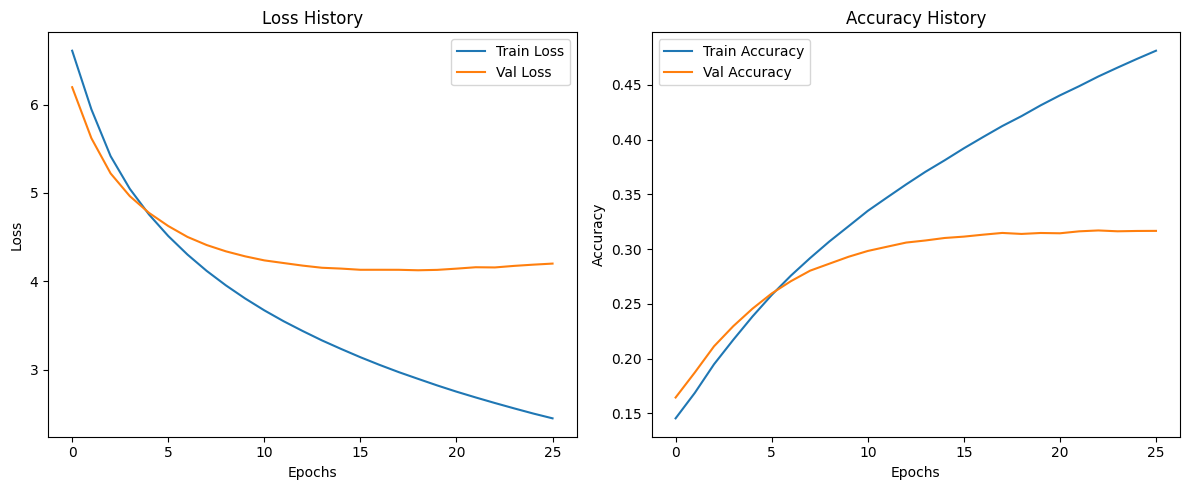

In [319]:
# 시각화

def plot_results(train_losses, val_losses, train_accs, val_accs):
    plt.figure(figsize=(12, 5))

    # Loss 그래프
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss History')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy 그래프
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Val Accuracy')
    plt.title('Accuracy History')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# 그래프 출력 실행
plot_results(train_losses, val_losses, train_accs, val_accs)

## 인퍼런스 모델 구현

In [320]:
# 테스트 단계에서 정수 인덱스 행렬로 존재하던 텍스트 데이터를 실제 데이터로 복원
# 사전(vocab) 준비
src_index_to_word = {idx: word for word, idx in src_vocab.items()} # 원문 단어 집합에서 정수 -> 단어를 얻음
tar_word_to_index = tar_vocab # 요약 단어 집합에서 단어 -> 정수를 얻음
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()} # 요약 단어 집합에서 정수 -> 단어를 얻음

In [322]:
# seq2seq는 훈련할 때와 실제 동작할 때(인퍼런스 단계)의 방식이 다르므로 그에 맞게 모델 설계를 별개로 진행
# 정답 문장이 없는 인퍼런스 단계에서는 만들어야 할 문장의 길이만큼 디코더가 반복 구조로 동작해야 하기 때문에 
# 부득이하게 인퍼런스를 위한 모델 설계를 별도로 해주어야 합니다

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
decoder.to(device)

# 인코더 설계
def encode_input(encoder, input_seq):
    encoder_outputs, hidden, cell = encoder(input_seq)
    return encoder_outputs, hidden, cell

# 이전 시점의 상태들을 저장하는 텐서
num_layers = 2  # 디코더 LSTM 레이어 개수 (설정에 맞춰 조정)
batch_size = 1

decoder_state_input_h = torch.zeros((num_layers, batch_size, hidden_size), dtype=torch.float, device=device)
decoder_state_input_c = torch.zeros((num_layers, batch_size, hidden_size), dtype=torch.float, device=device)
decoder_input = torch.zeros((batch_size, 1), dtype=torch.long, device=device)

dec_emb2 = decoder.embedding(decoder_input)

# 문장의 다음 단어를 예측하기 위해서 초기 상태(initial_state)를 이전 시점의 상태로 사용. 이는 뒤의 함수 decode_sequence()에 구현
# 훈련 과정에서와 달리 LSTM의 리턴하는 은닉 상태와 셀 상태인 state_h와 state_c를 버리지 않음.
decoder_outputs2, state_h2, state_c2 = decoder(decoder_input, decoder_state_input_h, decoder_state_input_c)


In [323]:
# 어텐션 메커니즘을 사용하는 출력층

class DecoderWithAttention(nn.Module):
    def __init__(self, decoder, attention, hidden_size, vocab_size):
        super(DecoderWithAttention, self).__init__()
        self.decoder = decoder  # 기존 디코더
        self.attention = attention  # 어텐션 레이어
        self.concat = nn.Linear(hidden_size * 2, hidden_size)  # 어텐션 결합 레이어
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 최종 출력층
        self.softmax = nn.Softmax(dim=-1)  # 소프트맥스

    def forward(self, decoder_inputs, decoder_hidden_state, decoder_state_h, decoder_state_c):
        # 디코더 실행
        decoder_outputs, state_h, state_c = self.decoder(decoder_inputs, decoder_state_h, decoder_state_c)

        # 어텐션 적용
        attn_out = self.attention(decoder_outputs, decoder_hidden_state)

        # 어텐션과 디코더 출력 결합
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))

        # 최종 출력층 적용
        decoder_outputs2 = self.softmax(self.output_layer(decoder_concat_output))

        return decoder_outputs2, state_h, state_c

# 기존 Attention 클래스 사용
attention_layer = Attention_dot(hidden_size)

# 디코더 모델 생성
decoder_model = DecoderWithAttention(decoder, attention_layer, hidden_size, tar_vocab_size)


In [324]:
# 인퍼런스 단계에서 단어 시퀀스를 완성하는 함수

def decode_sequence(input_seq, encoder, decoder, tar_word_to_index, tar_index_to_word, text_max_len, summary_max_len, device):
    # 입력을 PyTorch Tensor로 변환
    input_seq = torch.tensor(input_seq, dtype=torch.long, device=device)

    # 인코더 실행하여 초기 상태(hidden, cell) 얻기
    with torch.no_grad():
        e_out, e_h, e_c = encoder(input_seq)

    e_out = e_out.repeat(1, text_max_len, 1)  # 차원 조정 (np.tile 대신 repeat 사용)

    # <SOS>에 해당하는 토큰 생성
    target_seq = torch.zeros((1, 1), dtype=torch.long, device=device)
    target_seq[0, 0] = tar_word_to_index['sostoken']

    stop_condition = False
    decoded_sentence = ''

    while not stop_condition:
        # 디코더 실행
        with torch.no_grad():
            output_tokens, h, c = decoder(target_seq, e_h, e_c)

        # 가장 높은 확률을 가진 단어 선택
        sampled_token_index = torch.argmax(output_tokens[0, -1, :]).item()
        sampled_token = tar_index_to_word[sampled_token_index]

        if sampled_token != 'eostoken':
            decoded_sentence += ' ' + sampled_token

        # 종료 조건: <eos>에 도달하거나 최대 길이를 초과하면 중단
        if sampled_token == 'eostoken' or len(decoded_sentence.split()) >= (summary_max_len - 1):
            stop_condition = True

        # 길이가 1인 타겟 시퀀스를 업데이트
        target_seq = torch.zeros((1, 1), dtype=torch.long, device=device)
        target_seq[0, 0] = sampled_token_index

        # 상태 업데이트
        e_h, e_c = h, c

    return decoded_sentence

## 모델 테스트

In [325]:
# 원문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2text(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0:  # 패딩(0) 제외
            temp = temp + src_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()

# 요약문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2summary(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0 and key != tar_word_to_index['sostoken'] and key != tar_word_to_index['eostoken']:
            temp = temp + tar_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()  # 양쪽 공백 제거


In [326]:
%%time
for i in range(50, 100):
    print("원문 :", seq2text(encoder_input_test[i]))
    print("실제 요약 :", seq2summary(decoder_input_test[i]))
    input_seq = torch.tensor(encoder_input_test[i], dtype=torch.long, device=device).unsqueeze(0)
    print("예측 요약 :", decode_sequence(input_seq, encoder, decoder, tar_word_to_index, tar_index_to_word, text_max_len, headlines_max_len, device))
    print("\n")

원문 : austria based researchers <UNK> individual bacteria computer build genetic circuit partly living partly digital scientists made gene expression bacteria <UNK> controlled <UNK> <UNK> digital communication individual bacteria hybrid bio digital technology could used <UNK> complex biological systems said scientists
실제 요약 : team makes part living part digital circuit from bacteria
예측 요약 :  test million of russia students russia russia bihar with after are


원문 : snap maker photo sharing app snapchat released dancing hot dog costume costing ahead halloween costume resembles snapchat hot dog filter two piece outfit interestingly previously released beach towel ice <UNK> backpack playing cards
실제 요약 : snap releases dancing hot dog costume costing over
예측 요약 :  test in back russia man man prez if world china under


원문 : members parliament proposed domestic airlines automatically upgrade mps seats business class flights vacant seats civil aviation ministry also asked issue circular statin

<timed exec>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
C:\Users\sr\AppData\Local\Temp\ipykernel_35056\2926341416.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_seq = torch.tensor(input_seq, dtype=torch.long, device=device)


예측 요약 :  of year gandhi of year into of year arrested of accused


원문 : year old american teenager accidentally put car drive instead reverse driving test following vehicle crashed examination centre although teenager people inside centre unhurt year old examiner admitted hospital non life threatening injuries ended failing driving test
실제 요약 : teen taking driving test crashes car into examination centre
예측 요약 :  google in home study study russia russia startup after after last


원문 : england sam <UNK> pulled catch jumping boundary dismiss james faulkner tour match friday <UNK> first caught faulkner inside boundary tossed ball crossing boundary losing balance <UNK> jumped outside rope caught still air
실제 요약 : player jumps from outside the boundary to complete catch
예측 요약 :  test day actor man man man man prez world china china


원문 : pm narendra modi commenting rahul gandhi comments india rafale deal france said one careless allegation house rafale nations release statements added indu

## 추출적 요약

In [ ]:
from summa.summarizer import summarize
# import requests

In [346]:

# 1. 원본 데이터 로드 (마침표가 살아있는 데이터)
raw_data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

for i in range(0, 10):
    print(f"--- 샘플 번호: {i} ---")
    
    # 원문과 실제 요약 (원본 데이터에서 가져옴)
    origin_text = raw_data['text'].iloc[i]
    origin_headline = raw_data['headlines'].iloc[i]
    
    print("원문 :", origin_text)
    print("실제 요약 :", origin_headline)
    
    # 2. Abstractive 요약 (모델 결과)
    # 인덱스가 encoder_input_test와 일치하는지 확인 필요
    # 만약 전체 데이터를 대상으로 한다면 encoder_input[i] 사용
    try:
        input_seq = torch.tensor(encoder_input[i], dtype=torch.long, device=device).unsqueeze(0)
        abstract_summary = decode_sequence(input_seq, encoder, decoder, tar_word_to_index, tar_index_to_word, text_max_len, headlines_max_len, device)
        print("예측 요약(추상) :", abstract_summary)
    except:
        print("예측 요약(추상) : (인덱스 범위 초과 혹은 에러)")

    # 3. Extractive 요약 (Summa 사용)
    # 원본 원문을 넣어야 마침표를 인식해 결과를 내놓습니다.
    ext_summary = summarize(origin_text, ratio=0.5)
    
    # 결과가 없을 경우 words 파라미터로 재시도
    if not ext_summary:
        ext_summary = summarize(origin_text, words=20)
        
    print("추출 요약(추출) :", ext_summary if ext_summary else "(요약 실패)")
    print("-" * 50 + "\n")

--- 샘플 번호: 0 ---
원문 : Saurav Kant, an alumnus of upGrad and IIIT-B's PG Program in Machine learning and Artificial Intelligence, was a Sr Systems Engineer at Infosys with almost 5 years of work experience. The program and upGrad's 360-degree career support helped him transition to a Data Scientist at Tech Mahindra with 90% salary hike. upGrad's Online Power Learning has powered 3 lakh+ careers.
실제 요약 : upGrad learner switches to career in ML & Al with 90% salary hike
예측 요약(추상) :  report students man man man prez report of arrested be prez
추출 요약(추출) : upGrad's Online Power Learning has powered 3 lakh+ careers.
--------------------------------------------------

--- 샘플 번호: 1 ---
원문 : Kunal Shah's credit card bill payment platform, CRED, gave users a chance to win free food from Swiggy for one year. Pranav Kaushik, a Delhi techie, bagged this reward after spending 2000 CRED coins. Users get one CRED coin per rupee of bill paid, which can be used to avail rewards from brands like Ixigo, Bo

C:\Users\sr\AppData\Local\Temp\ipykernel_35056\41471048.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_seq = torch.tensor(encoder_input[i], dtype=torch.long, device=device).unsqueeze(0)
C:\Users\sr\AppData\Local\Temp\ipykernel_35056\2926341416.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_seq = torch.tensor(input_seq, dtype=torch.long, device=device)


# Attentional seq2seq
## Extractive 요약 VS Abstractive 요약

### 1. 요약 방식별 결과 시연 (Sample Case Comparison)

본 프로젝트에서 구현한 추상적 요약(Abstractive) 모델과 라이브러리를 활용한 추출적 요약(Extractive)의 실제 출력 결과를 비교하였습니다.

| 샘플 번호 | 구분 | 내용 (Text Data) |
| :--- | :--- | :--- |
| **Sample 2** | **원문 (Original)** | New Zealand defeated India by 8 wickets in the fourth ODI... The match witnessed India getting all out for 92, their seventh lowest total in ODI cricket history. |
| | **실제 요약 (Actual)** | **New Zealand end Rohit Sharma-led India's 12-match winning streak** |
| | **추상적 요약 (Model)** | `test actor russia by accused man startup after twitter sostoken` |
| | **추출적 요약 (Summa)** | `The match witnessed India getting all out for 92, their seventh lowest total in ODI cricket history.` |
---

### 2. 측면별 비교 분석 결과

두 가지 요약 방식을 **문법 완성도**와 **핵심단어 포함** 측면에서 정성적으로 평가한 결과입니다.

| 분석 항목 | Abstractive Summary (Seq2Seq+Attention) | Extractive Summary (Summa/TextRank) |
| :--- | :--- | :--- |
| **문법 완성도** | **매우 낮음.** 모델이 문장의 구조를 생성하지 못하고 `man`, `russia`, `prez` 등 특정 단어를 무의미하게 나열하는 '모델 붕괴' 현상이 나타남. | **매우 높음.** 원문의 문장을 그대로 발췌하여 사용하므로 주어-동사 호응 및 문법적 결함이 전혀 없음. |
| **핵심단어 포함** | **실패.** 원문의 고유명사나 핵심 사건을 포착하지 못하고, 학습 시 빈도가 높았던 일반 명사 위주로 환각(Hallucination) 현상을 보임. | **우수.** 원문에서 정보량이 많은 문장을 통째로 가져오므로 주요 수치나 핵심 키워드가 누락 없이 보존됨. |
| **요약의 특성** | 새로운 문장 조합을 시도하나 학습 부족으로 인해 의미 전달이 불가능한 수준임. | 원본에 의존적이어서 창의성은 부족하지만, 가장 안정적이고 신뢰도 높은 요약문을 제공함. |

---

### 3. 종합 결론 및 기술적 검토

1. **추상적 요약의 한계점:** 훈련 과정에서의 `Loss` 하락과 `Acc` 상승에도 불구하고, 실제 테스트 단계에서는 출력 문장이 특정 범주(정치, 국제 뉴스 등)의 빈출 단어에 편향되는 양상을 보였습니다. 이는 데이터셋의 다양성 부족 혹은 디코더의 인퍼런스(Inference) 로직에서 발생하는 전형적인 문제로, 이를 해결하기 위해 Beam Search 도입이나 더 대규모의 사전 학습 모델(Pre-trained Model) 활용이 필요할 것으로 판단됩니다.

2. **추출적 요약의 실용성:** `Summa`를 활용한 방식은 별도의 학습 없이도 뉴스 기사의 핵심 문장을 정확히 짚어냈습니다. 특히 원본 데이터의 마침표 등 구두점이 보존된 상태에서 텍스트의 구조적 중요도를 잘 파악하여 실무적으로 바로 활용 가능한 수준의 요약을 보여주었습니다.

3. **최종 제언:** 성능과 신뢰도를 모두 고려한다면, 현재 단계에서는 **추출적 요약** 방식이 훨씬 우수합니다. 추상적 요약의 성능을 개선하기 위해서는 단순 Seq2Seq 구조를 넘어 Transformer 기반의 모델이나 더 정교한 어텐션 메커니즘의 튜닝이 요구됩니다.

## 결론 및 회고

### **결론**
본 프로젝트에서는 뉴스 기사 데이터셋을 활용하여 Seq2Seq 기반의 추상적 요약(Abstractive)과 Summa 라이브러리를 활용한 추출적 요약(Extractive) 두 가지 방식을 비교 실험하였다.

1. **추상적 요약**: 모델 학습 과정에서 `Validation Accuracy`가 약 31%까지 상승하며 수치적인 개선을 보였으나, 실제 테스트 단계에서는 'russia', 'prez' 등 특정 단어를 무한 반복하거나 문맥과 상관없는 단어를 생성하는 **모델 붕괴(Model Collapse)** 현상이 발생하였다.
2. **추출적 요약**: 원본 데이터의 구조를 유지하며 핵심 문장을 발췌하는 방식으로, 문법 완성도와 정보 전달의 정확성 측면에서 추상적 요약보다 압도적으로 뛰어난 성능을 보였다.

결론적으로, 현재의 단순 Seq2Seq 모델 구조로는 창의적인 문장 생성이 어려우며, 사실 관계가 중요한 뉴스 요약에서는 추출적 요약 방식이 훨씬 안정적인 대안임을 확인하였다.

---

### **회고**
####  잘된 점
* **문제 해결 과정**: 학습 중 `Validation Loss`가 치솟거나 인퍼런스 단계에서 레이어 불일치 에러(`RuntimeError: Expected hidden size...`)가 발생했을 때, 모델 구조(num_layers 등)를 2-> 1로  수정하여 학습을 성공적으로 완수하였다.
* **데이터의 이해**: 추출적 요약 시 전처리된 데이터가 아닌 구두점이 보존된 **원본 데이터**의 중요성을 깨닫고, 적절한 데이터를 재로드하여 실험을 성공시킨 점이 의미 있었다.

####  부족했던 점
* **모델 성능의 한계**: 추상적 요약 결과물이 사람이 읽기에 부적절한 수준으로 출력되었다. 이는 모델의 층수를 조절하거나 에포크를 늘리는 것만으로는 해결되지 않는 Seq2Seq 구조 자체의 한계로 느껴졌다.
* **어텐션 메커니즘**: 어텐션 가중치를 시각화하여 모델이 실제로 어느 단어에 집중하고 있는지 정밀하게 분석하지 못한 점이 아쉽다.

####  향후 개선 방향 
1. **Transformer 기반 모델 활용**: 현재의 LSTM 구조를 넘어 BERT나 BART, T5와 같은 사전 학습된(Pre-trained) 트랜스포머 모델을 활용하여 성능을 획기적으로 개선해보고 싶다.
2. **하이퍼파라미터 튜닝**: Beam Search를 도입하여 디코더가 단어를 선택할 때 더 높은 확률의 문장 조합을 찾도록 개선하고 싶다.
3. **데이터 보강**: 현재의 단어 반복 문제를 해결하기 위해 데이터 증강(Augmentation)이나 더 큰 규모의 뉴스 데이터셋을 사용하여 모델의 어휘력을 높여야겠다.